# Monte Carlo Methods

**Monte Carlo methods** are computational algorithms that use **random sampling** to solve mathematical, statistical, and computational problems.

Instead of calculating an exact solution, Monte Carlo methods estimate the answer by performing many random experiments. Since most problems are extremely different (or impossible) to solve analytically, using computational methods like Monte Carlo can be useful.

In [1]:
# preliminaries

import random
import math
import matplotlib.pyplot as plt
import numpy as np

Consider the problem of estimating $\pi$. We'll take a unit circle inscribed on a square:

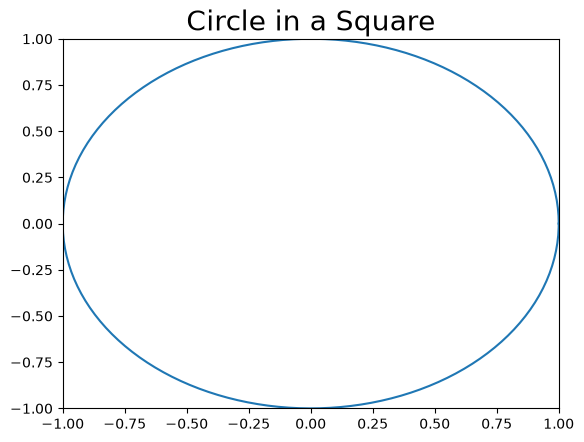

In [2]:
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta))
plt.title("Circle in a Square",fontsize=20)
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.show()

And we will throw thousands of darts at the square and see the proportion of darts that land in the circle:

In [3]:
def montecircle(n):
    # make random points

    x = np.random.uniform(-1, 1, n)
    y = np.random.uniform(-1, 1, n)

    # determine inside

    inside = (x**2+y**2)<= 1
    plt.scatter(x[inside], y[inside], s=5, label="Accepted")
    plt.scatter(x[~inside], y[~inside], s=5, label="Rejected")

    #plotting

    theta = np.linspace(0, 2*np.pi, 300)
    plt.plot(np.cos(theta), np.sin(theta))
    plt.title("Monte Carlo on the Circle")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    #compute pi

    pi = 4*np.mean(inside)
    print('Pi is about: ',pi)


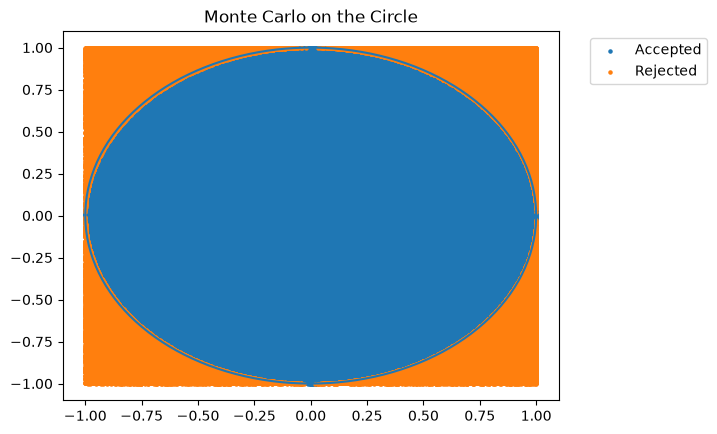

Pi is about:  3.138992


In [4]:
montecircle(1000000)

Mathematical idea: the area of the square is four, the area of the circle is $\pi$, and so $\pi \approx
4\cdot\frac{\text{Points Inside Circle}}
{\text{Total Points}}$.

Similarly, we can compute the probability of a needle landing on a line:

In [5]:
def buffon_needles_plot(num_needles):
    lines = list(range(0, 5))

    xs1, ys1, xs2, ys2 = [], [], [], []
    hits = 0
    L = 1

    for i in range(num_needles):
        x_center = random.random() * 4
        y_center = random.random() * 1
        theta = random.random() * math.pi

        dx = (L/2) * math.cos(theta)
        dy = (L/2) * math.sin(theta)

        x1 = x_center - dx
        x2 = x_center + dx

        # check if needle crosses a line
        # crossing if floor(x1) != floor(x2)
        if int(x1) != int(x2):
            hits += 1

        xs1.append(x1)
        ys1.append(y_center - dy)
        xs2.append(x2)
        ys2.append(y_center + dy)

    pi_estimate = (2 * num_needles) / hits if hits > 0 else float('inf')

    fig, ax = plt.subplots(figsize=(6, 6))

    for x in lines:
        ax.axvline(x)

    for i in range(num_needles):
        ax.plot([xs1[i], xs2[i]], [ys1[i], ys2[i]])

    ax.set_xlim(0, 4)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    plt.title(f"Buffon's Needle Visualization — Estimated $\pi$ ≈ {pi_estimate:.5f}")
    plt.show()


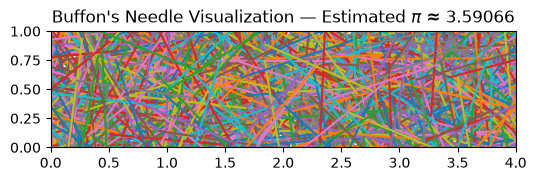

In [6]:
buffon_needles_plot(2000)

### Lab Problems

---

1. Generate 100,000 samples using `np.random.uniform(0,1)` and compute the average so far at each sample. Plot the data. What do you notice?

---

2. We want to compute $\int_0^1 x^2dx$. To do so, generate random points between 0 and 1. Accept them if they are below and reject them if they are above. Compute the average of the accepted values and plot the accepted vs rejected points.

---

3. Write a function that will do Problem 2 for any function and bounds.

---


4. Estimate $\pi$ using one of the functions from lecture with:

- 1,000 samples
- 10,000 samples
- 100,000 samples

Compare the results with the true value of $\pi$.

### Lab Key*

1.

2.

3.

4.